# Breast Cancer Wisconsin (Original) - Pre-ML Analysis

**Dataset**: Breast Cancer Wisconsin (Original)

**Descripción**: Dataset de diagnóstico de cáncer de mama obtenido del University of Wisconsin Hospitals. Contiene características de células obtenidas mediante aspiración con aguja fina (FNA) de masas mamarias.

**Objetivo ML**: Clasificación binaria - predecir si un tumor es **benigno (2)** o **maligno (4)** basándose en 9 características celulares.

**Features**: 9 atributos numéricos (escala 1-10): Clump Thickness, Uniformity of Cell Size, Uniformity of Cell Shape, Marginal Adhesion, Single Epithelial Cell Size, Bare Nuclei, Bland Chromatin, Normal Nucleoli, Mitoses.

**Target**: Class (2 = benign, 4 = malignant)

**Particularidades**:
- Incluye ID del paciente (no predictivo, se debe eliminar)
- 16 valores faltantes en columna 'Bare Nuclei' (marcados como '?')
- Clases desbalanceadas: 65.5% benign, 34.5% malignant

---

## PASO 1: Cargar dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definir nombres de columnas según documentación
column_names = [
    'id',
    'clump_thickness',
    'uniformity_cell_size',
    'uniformity_cell_shape',
    'marginal_adhesion',
    'single_epithelial_cell_size',
    'bare_nuclei',
    'bland_chromatin',
    'normal_nucleoli',
    'mitoses',
    'class'
]

# Cargar dataset (? como NaN)
df = pd.read_csv('breast-cancer-wisconsin.data', 
                 names=column_names,
                 na_values='?')

## PASO 2: Ver estructura

In [2]:
df.head()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [3]:
df.shape

(699, 11)

In [4]:
df.dtypes.to_frame(name='dtype')

,dtype
id,int64
clump_thickness,int64
uniformity_cell_size,int64
uniformity_cell_shape,int64
marginal_adhesion,int64
single_epithelial_cell_size,int64
bare_nuclei,float64
bland_chromatin,int64
normal_nucleoli,int64
mitoses,int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           699 non-null    int64  
 1   clump_thickness              699 non-null    int64  
 2   uniformity_cell_size         699 non-null    int64  
 3   uniformity_cell_shape        699 non-null    int64  
 4   marginal_adhesion            699 non-null    int64  
 5   single_epithelial_cell_size  699 non-null    int64  
 6   bare_nuclei                  683 non-null    float64
 7   bland_chromatin              699 non-null    int64  
 8   normal_nucleoli              699 non-null    int64  
 9   mitoses                      699 non-null    int64  
 10  class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


## PASO 3: Valores faltantes

In [6]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Pct': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if not missing_df.empty:
    display(missing_df)

,Missing_Count,Missing_Pct
bare_nuclei,16,2.288984


## PASO 4: Gráfico simple del target

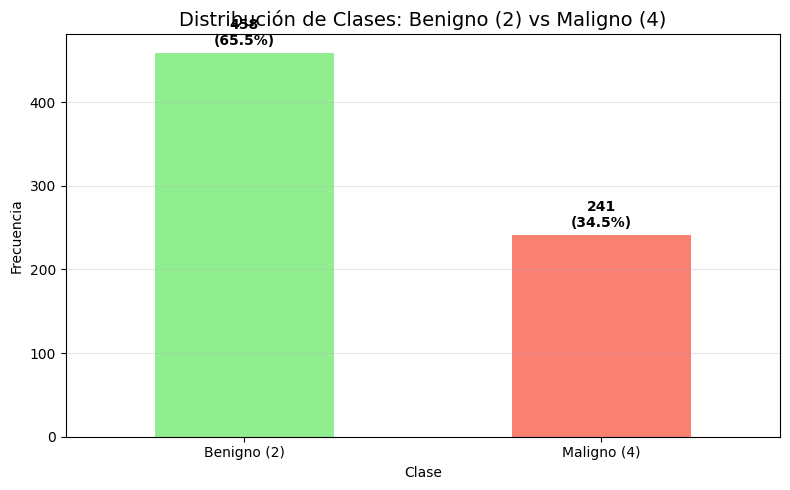

In [7]:
# Distribución de clases
class_counts = df['class'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribución de Clases: Benigno (2) vs Maligno (4)', fontsize=14)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['Benigno (2)', 'Maligno (4)'], rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar porcentajes
total = len(df)
for i, v in enumerate(class_counts):
    plt.text(i, v + 10, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## LIMPIEZA

### Eliminar columna ID (no predictiva)

In [8]:
df = df.drop('id', axis=1)

### Tratar valores faltantes

Solo hay 16 valores faltantes (~2.3%) en 'bare_nuclei'. Estrategia: eliminar filas.

In [9]:
# Eliminar filas con valores faltantes
df_clean = df.dropna()

print(f"Filas antes: {len(df)}")
print(f"Filas después: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")

Filas antes: 699
Filas después: 683
Filas eliminadas: 16


### Verificar outliers (opcional - solo inspección visual)

In [10]:
df_clean.describe()

,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


**Observación**: Todos los features están en escala 1-10 según documentación. No hay outliers evidentes.

---
## PREPROCESAMIENTO

### Encoding

No hay variables categóricas. Solo convertir target a binario (0 = benign, 1 = malignant).

In [11]:
# Convertir clase: 2 (benign) -> 0, 4 (malignant) -> 1
df_clean['class'] = (df_clean['class'] == 4).astype(int)

df_clean['class'].value_counts().sort_index()

class
0    444
1    239
Name: count, dtype: int64

### Separar features (X) y target (y)

In [12]:
X = df_clean.drop('class', axis=1)
y = df_clean['class']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (683, 9)
y shape: (683,)


### Train/Test Split Manual (80-20)

In [13]:
# Fijar semilla
np.random.seed(42)

# Crear índices aleatorios
n = len(X)
indices = np.random.permutation(n)

# Split 80-20
split_idx = int(0.8 * n)
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

# Separar datos
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Train size: {len(X_train)} ({len(X_train)/n*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/n*100:.1f}%)")

Train size: 546 (79.9%)
Test size: 137 (20.1%)


### Convertir a float ANTES del escalado

In [14]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### Feature Scaling Manual (Standardization)

In [15]:
# Calcular media y std del train
train_mean = X_train.mean()
train_std = X_train.std()

# Aplicar scaling
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

# Asegurar tipo float después de scaling
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("Escalado completado")
print(f"Train mean (después): {X_train_scaled.mean().mean():.6f}")
print(f"Train std (después): {X_train_scaled.std().mean():.6f}")

Escalado completado
Train mean (después): 0.000000
Train std (después): 1.000000


---
## VALIDACIÓN

### 1. Verificar Data Leakage

In [16]:
# Verificar que no hay índices compartidos
train_indices = set(X_train.index)
test_indices = set(X_test.index)
overlap = train_indices.intersection(test_indices)

print(f"Índices en train: {len(train_indices)}")
print(f"Índices en test: {len(test_indices)}")
print(f"Overlap: {len(overlap)}")
print(f"✓ Sin data leakage" if len(overlap) == 0 else "✗ HAY DATA LEAKAGE")

Índices en train: 546
Índices en test: 137
Overlap: 0
✓ Sin data leakage


### 2. Verificar NaN e infinitos

In [17]:
# Verificar NaN
train_nan = X_train_scaled.isnull().sum().sum()
test_nan = X_test_scaled.isnull().sum().sum()

# Verificar infinitos
train_inf = np.isinf(X_train_scaled).sum().sum()
test_inf = np.isinf(X_test_scaled).sum().sum()

print(f"Train - NaN: {train_nan}, Inf: {train_inf}")
print(f"Test - NaN: {test_nan}, Inf: {test_inf}")
print(f"✓ Sin problemas" if (train_nan + test_nan + train_inf + test_inf) == 0 else "✗ HAY PROBLEMAS")

Train - NaN: 0, Inf: 0
Test - NaN: 0, Inf: 0
✓ Sin problemas


### 3. Comparar distribuciones Train vs Test

In [18]:
# Distribución del target
train_target_dist = y_train.value_counts(normalize=True).sort_index()
test_target_dist = y_test.value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Train': train_target_dist,
    'Test': test_target_dist
})

comparison.index = ['Benign (0)', 'Malignant (1)']
comparison

,Train,Test
Benign (0),0.655678,0.627737
Malignant (1),0.344322,0.372263


---
## RESUMEN FINAL

In [19]:
print("="*60)
print("DATASET PREPARADO PARA ML")
print("="*60)
print(f"\nDatos originales: {len(df)} filas")
print(f"Datos limpios: {len(df_clean)} filas")
print(f"Features: {X_train_scaled.shape[1]}")
print(f"\nTrain: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")
print(f"\nClases:")
print(f"  - Benign (0): {(y_train == 0).sum()} train, {(y_test == 0).sum()} test")
print(f"  - Malignant (1): {(y_train == 1).sum()} train, {(y_test == 1).sum()} test")
print("\n" + "="*60)

DATASET PREPARADO PARA ML

Datos originales: 699 filas
Datos limpios: 683 filas
Features: 9

Train: (546, 9)
Test: (137, 9)

Clases:
  - Benign (0): 358 train, 86 test
  - Malignant (1): 188 train, 51 test

